<a href="https://colab.research.google.com/github/va4756/bigdata_raejung/blob/main/quebin_data_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01.DCGAN

In [74]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [80]:
import sys

# 코랩의 경우 깃허브 저장소로부터 utils.py를 다운로드 합니다.
if 'google.colab' in sys.modules:
    !wget https://raw.githubusercontent.com/rickiepark/Generative_Deep_Learning_2nd_Edition/main/notebooks/utils.py
    !mkdir -p notebooks
    !mv utils.py notebooks

--2026-05-06 09:49:01--  https://raw.githubusercontent.com/rickiepark/Generative_Deep_Learning_2nd_Edition/main/notebooks/utils.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 771 [text/plain]
Saving to: ‘utils.py’

utils.py            100%[===================>]     771  --.-KB/s    in 0s      

2026-05-06 09:49:01 (51.1 MB/s) - ‘utils.py’ saved [771/771]



In [81]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import (
    layers,
    models,
    callbacks,
    losses,
    utils,
    metrics,
    optimizers,
)

from notebooks.utils import display, sample_batch

In [82]:
IMAGE_SIZE = 64
CHANNELS = 1
BATCH_SIZE = 128
Z_DIM = 100
EPOCHS = 100 # 훈련이 오래 걸려 에포크 횟수를 300에서 100으로 줄입니다.
LOAD_MODEL = False
ADAM_BETA_1 = 0.5
ADAM_BETA_2 = 0.999
LEARNING_RATE = 0.0002
NOISE_PARAM = 0.1

In [84]:
# 코랩일 경우 노트북에서 celeba 데이터셋을 받습니다.
if 'google.colab' in sys.modules:
    # # 캐글-->Setttings-->API-->Create New Token에서
    # # kaggle.json 파일을 만들어 코랩에 업로드하세요.
    # from google.colab import files
    # files.upload()
    # !mkdir ~/.kaggle
    # !cp kaggle.json ~/.kaggle/
    # !chmod 600 ~/.kaggle/kaggle.json
    # 데이터셋을 다운로드하고 압축을 해제합니다.
    !kaggle datasets download -d joosthazelzet/lego-brick-images
    #
    # 캐글에서 다운로드가 안 될 경우 역자의 드라이브에서 다운로드할 수 있습니다.
    # import gdown
    # gdown.download(id='1qd50QDZtr_NYFiFVdp0sIvGDwTT3mMEQ')
    !unzip -q lego-brick-images.zip
    # output 디렉토리를 만듭니다.
    !mkdir output

Dataset URL: https://www.kaggle.com/datasets/joosthazelzet/lego-brick-images
License(s): GPL-2.0
lego-brick-images.zip: Skipping, found more recently modified local copy (use --force to force download)
replace Collada models/14719 flat tile corner 2x2.dae? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
mkdir: cannot create directory ‘output’: File exists


In [55]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [56]:
def display(images, n=16, cmap="gray"):
    """
    images: torch.Tensor or numpy array
    shape: (B, C, H, W) or (B, H, W)
    """
    if isinstance(images, torch.Tensor):
        images = images.detach().cpu()

    # 채널 차원 처리
    if images.ndim == 4:
        images = images[:n]
    elif images.ndim == 3:
        images = images[:n]
    else:
        raise ValueError("이미지 shape이 올바르지 않습니다.")

    # [-1,1] → [0,1]
    if images.min() < 0:
        images = (images + 1) / 2

    n = min(n, len(images))
    grid_size = int(np.sqrt(n))

    plt.figure(figsize=(6,6))
    for i in range(n):
        plt.subplot(grid_size, grid_size, i+1)
        img = images[i]

        if img.ndim == 3:
            img = img.squeeze()

        plt.imshow(img, cmap=cmap)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [57]:
def sample_batch(dataloader):
    """
    DataLoader에서 batch 하나 추출
    """
    imgs, _ = next(iter(dataloader))
    return imgs

In [58]:
!ls -R

.:
data  dataset  drive  notebooks  sample_data

./data:
MNIST

./data/MNIST:
raw

./data/MNIST/raw:
t10k-images-idx3-ubyte	   train-images-idx3-ubyte
t10k-images-idx3-ubyte.gz  train-images-idx3-ubyte.gz
t10k-labels-idx1-ubyte	   train-labels-idx1-ubyte
t10k-labels-idx1-ubyte.gz  train-labels-idx1-ubyte.gz

./dataset:

./drive:
MyDrive  Othercomputers

./drive/MyDrive:
 BigData_datas
 BreakOut_Game
 ch12_02.ipynb
 ch12_03.ipynb
 ch13_07.ipynb
 ch14_05.ipynb
 ch15_03.ipynb
 CharlesBookClub.csv
'Colab Notebooks'
 Dacon_datas
 data100
 DeepLearningforComputerVision_Code
 EDA.csv
 GAN_collections
 google_tensorflow
 InteractiveSheet_2025-03-07_06_53_42.gsheet
 kaggle_dataset
 NadoCoding
 nmt-master
 PirateMaker
 SentiWord_Dict.txt
 tm.csv
 Zelda_main
'연간 가계부.gsheet'
 유방암진단.csv
 일정.gsheet
 주택가격.csv
 판다스_100제_문제_최종_v2.ipynb
'한글과컴퓨터 한글 2007.lnk'
'할 일 목록.gsheet'

./drive/MyDrive/BigData_datas:
air_pollution_data.csv	data.csv	mtcars.csv

In [60]:
!ls lego-brick-images/*

ls: cannot access 'lego-brick-images/*': No such file or directory


In [59]:
!ls lego-brick-images

ls: cannot access 'lego-brick-images': No such file or directory


In [48]:
import os

def find_data_root(base_path="./"):
    for root, dirs, files in os.walk(base_path):
        # 클래스 폴더 안에 이미지가 있으면 그 상위가 root
        for d in dirs:
            sub = os.path.join(root, d)
            if os.path.isdir(sub):
                if any(f.lower().endswith((".png", ".jpg", ".jpeg")) for f in os.listdir(sub)):
                    print("✔ 데이터 경로 발견:", root)
                    return root
    raise Exception("❌ ImageFolder 구조를 찾을 수 없습니다")

data_dir = find_data_root("./lego-brick-images")

Exception: ❌ ImageFolder 구조를 찾을 수 없습니다

In [41]:
def display(images, n=16):
    """
    이미지 grid 출력
    images: torch tensor or numpy (B, C, H, W)
    """
    if isinstance(images, torch.Tensor):
        images = images.detach().cpu()

    # [0,1] 또는 [-1,1] → [0,1]로 보정
    if images.min() < 0:
        images = (images + 1) / 2

    images = images[:n]

    plt.figure(figsize=(6,6))
    for i in range(len(images)):
        plt.subplot(int(np.sqrt(n)), int(np.sqrt(n)), i+1)
        img = images[i].squeeze()
        plt.imshow(img, cmap="gray")
        plt.axis("off")
    plt.show()

In [42]:
def sample_batch(dataloader):
    """
    dataloader에서 batch 하나 가져오기
    """
    imgs, _ = next(iter(dataloader))
    return imgs

In [43]:
transform = transforms.Compose([
    transforms.Resize(64),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])  # [-1,1]
])

dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

dataloader = DataLoader(dataset, batch_size=128, shuffle=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 40.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.00MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.43MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.09MB/s]


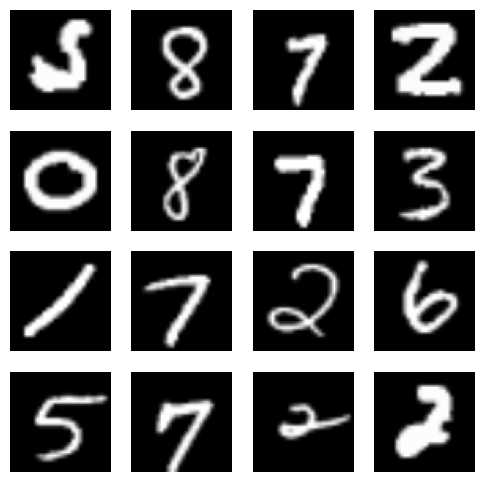

In [44]:
batch = sample_batch(dataloader)
display(batch)

In [45]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

IMAGE_SIZE = 64
BATCH_SIZE = 128

transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize(IMAGE_SIZE),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])  # [-1,1]
])

dataset = datasets.ImageFolder(
    root=data_dir,
    transform=transform
)

dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

print("데이터 개수:", len(dataset))
print("클래스:", dataset.classes)

FileNotFoundError: [Errno 2] No such file or directory: './lego-brick-images'

In [20]:
# 1. kaggle.json 업로드
from google.colab import files
files.upload()

# 2. kaggle 설정
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# 3. 데이터 다운로드
!kaggle datasets download -d joosthazelzet/lego-brick-images

# 4. 압축 해제
!unzip -q lego-brick-images.zip

# 5. 구조 확인
!ls

KeyboardInterrupt: 

In [17]:
# 1.라이브러리 & 설정
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

IMAGE_SIZE = 64
BATCH_SIZE = 128
Z_DIM = 100
EPOCHS = 100

LR = 0.0002
BETA1 = 0.5
BETA2 = 0.999
NOISE_PARAM = 0.1

In [18]:
# 2.데이터 로드 (Colab 기준) -> 👉 Lego 데이터 대신 ImageFolder 구조 사용
transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize(IMAGE_SIZE),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])  # [-1, 1]
])

dataset = datasets.ImageFolder(root="./dataset", transform=transform)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

FileNotFoundError: Found no valid file for the classes class0. Supported extensions are: .jpg, .jpeg, .png, .ppm, .bmp, .pgm, .tif, .tiff, .webp

In [ ]:
# 3.Discriminator
class Discriminator(nn.Module):
    def __init_